فصل اول: سیگنال، ریاضیات و ابزارها

درس 2: 

# 🧩 رمزگشایی صدا با تبدیل فوریه

### 1️⃣ نصب و ایمپورت‌ها

In [ ]:
%pip install numpy matplotlib librosa sounddevice soundfile --quiet

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import sounddevice as sd
import soundfile as sf


### 2️⃣ ضبط یک صدای کوتاه برای آزمایش

In [43]:
duration = 2  # seconds
sr = 44100

print("🎙️ لطفا یکی از حروف صدادار مثل 'آ' یا 'او' را بگویید...")
recording = sd.rec(int(duration * sr), samplerate=sr, channels=1)
sd.wait()
sf.write("vowel.wav", recording, sr)
print("✅ vowel.wav صدای شما ذخیره شد به نام ")

🎙️ لطفا یکی از حروف صدادار مثل 'آ' یا 'او' را بگویید...
✅ vowel.wav صدای شما ذخیره شد به نام 


### 3️⃣ نمایش شکل موج در حوزه زمان

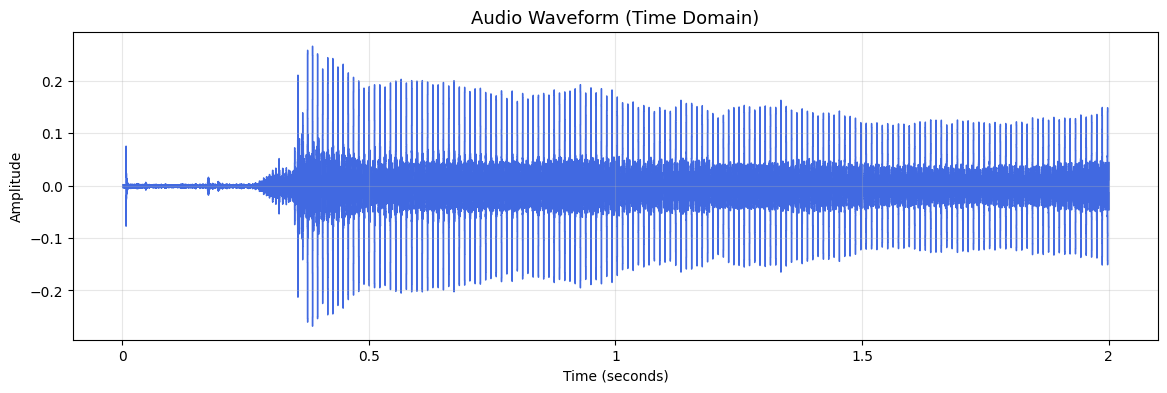

In [44]:
y, sr = librosa.load("vowel.wav", sr=None)

plt.figure(figsize=(14,4))
librosa.display.waveshow(y, sr=sr, color='royalblue')
plt.title("Audio Waveform (Time Domain)", fontsize=13)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

### 4️⃣ اجرای تبدیل فوریه سریع (FFT)

In [45]:
fft_result = np.fft.fft(y)
fft_magnitude = np.abs(fft_result)
freqs = np.fft.fftfreq(len(fft_result), d=1/sr)

### 5️⃣ رسم طیف فرکانسی کامل

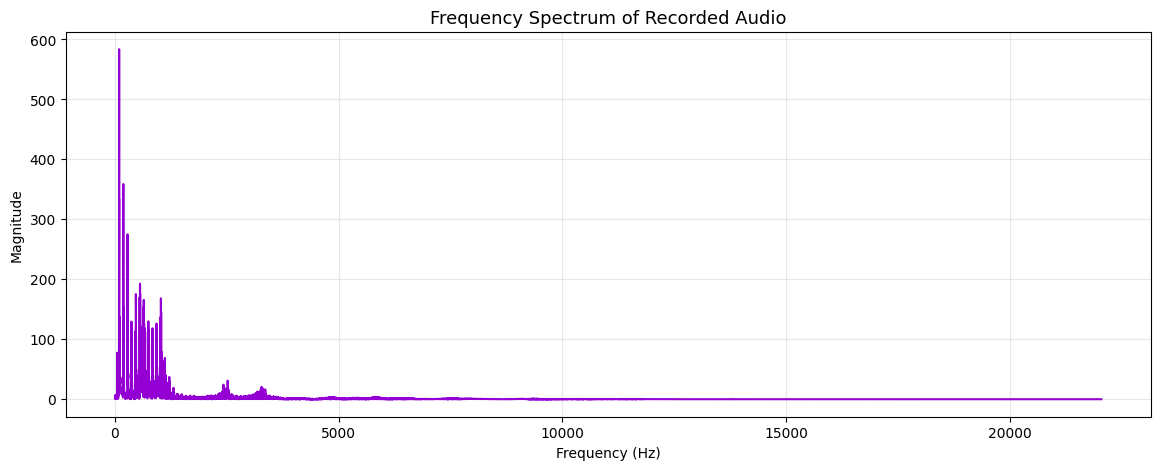

In [46]:
plt.figure(figsize=(14,5))
plt.plot(freqs[:len(freqs)//2], fft_magnitude[:len(freqs)//2], color='darkviolet')
plt.title("Frequency Spectrum of Recorded Audio", fontsize=13)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True, alpha=0.3)
plt.show()

### 6️⃣ نرمال‌سازی و بزرگ‌نمایی محدوده پایین فرکانس (برای تشخیص هارمونیک‌ها)

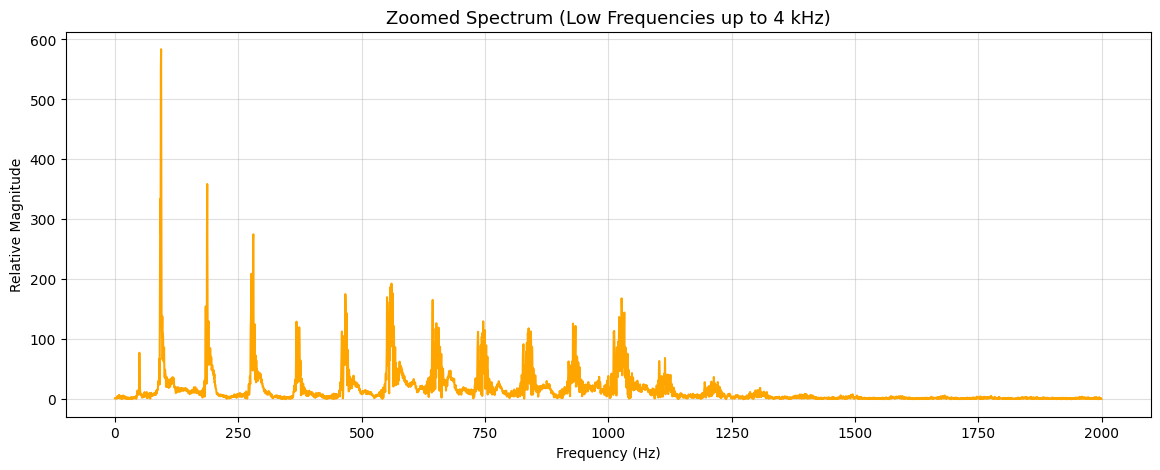

In [47]:
plt.figure(figsize=(14,5))
plt.plot(freqs[:4000], fft_magnitude[:4000], color='orange')
plt.title("Zoomed Spectrum (Low Frequencies up to 4 kHz)", fontsize=13)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative Magnitude")
plt.grid(True, alpha=0.4)
plt.show()

### 7️⃣ مقایسه صدادار و بی‌صدا

In [51]:
print("🎙️ ...حالا یکی از حروف بی‌صدا مثل 'س' یا 'ش' را بگویید")
recording2 = sd.rec(int(duration * sr), samplerate=sr, channels=1)
sd.wait()
sf.write("consonant.wav", recording2, sr)
print("✅ consonant.wav صدای صامت ذخیره شد به نام ")

y2, sr = librosa.load("consonant.wav", sr=None)
fft_result2 = np.fft.fft(y2)
fft_magnitude2 = np.abs(fft_result2)
freqs2 = np.fft.fftfreq(len(fft_result2), d=1/sr)

🎙️ ...حالا یکی از حروف بی‌صدا مثل 'س' یا 'ش' را بگویید
✅ consonant.wav صدای صامت ذخیره شد به نام 


### 8️⃣ رسم مقایسه طیفی صدادار و بی‌صدا

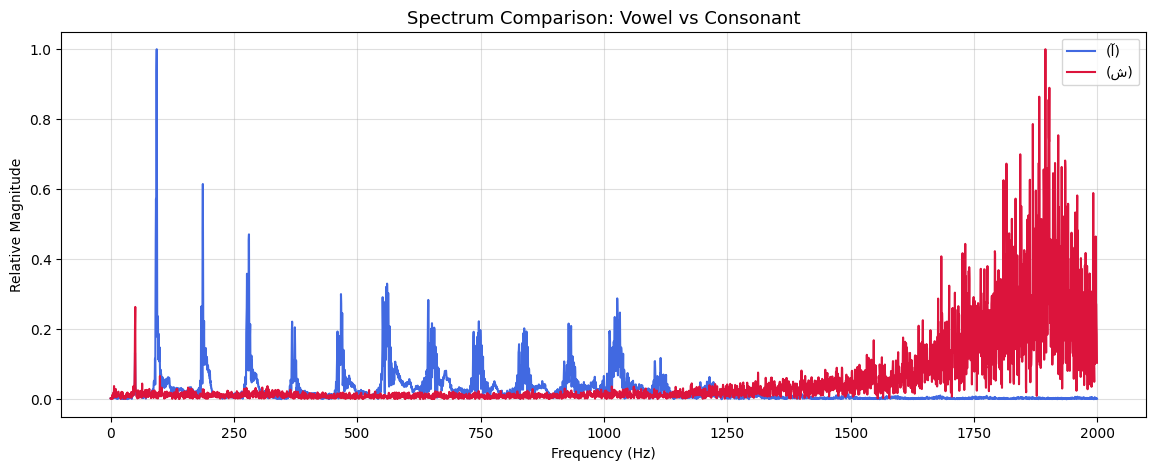

In [53]:
plt.figure(figsize=(14,5))
plt.plot(freqs[:4000], fft_magnitude[:4000]/np.max(fft_magnitude), label="(آ)", color='royalblue')
plt.plot(freqs2[:4000], fft_magnitude2[:4000]/np.max(fft_magnitude2), label="(ش)", color='crimson')
plt.title("Spectrum Comparison: Vowel vs Consonant", fontsize=13)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative Magnitude")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

### 1️⃣0️⃣  تمرین ساده: تبديل فوريه موج سينوسی خالص

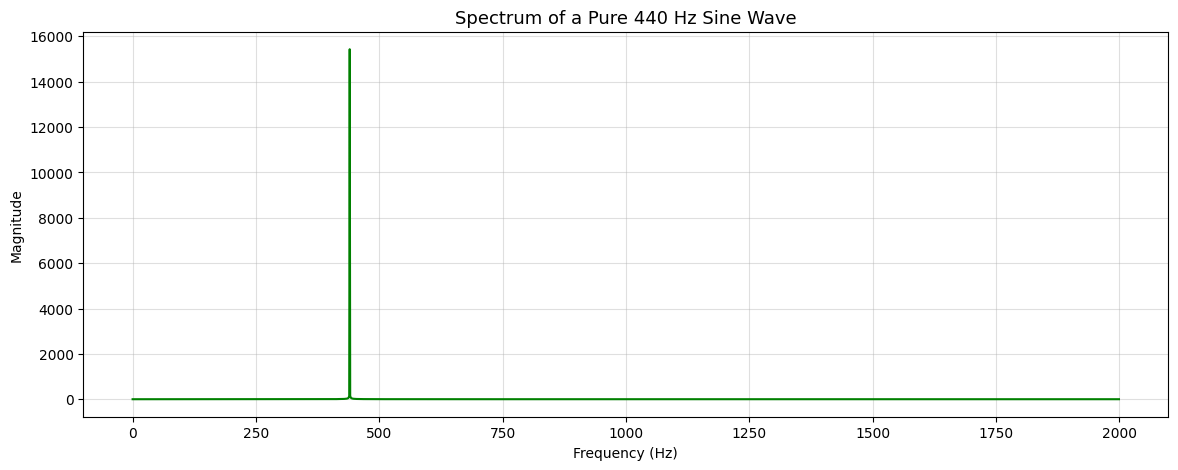

In [54]:
f = 440  # فرکانس پایه (نت لا)
t = np.linspace(0, 1, sr)
A = 0.7
y_sine = A * np.sin(2 * np.pi * f * t)

fft_sine = np.fft.fft(y_sine)
freqs_sine = np.fft.fftfreq(len(y_sine), 1/sr)

plt.figure(figsize=(14,5))
plt.plot(freqs_sine[:2000], np.abs(fft_sine[:2000]), color='green')
plt.title("Spectrum of a Pure 440 Hz Sine Wave", fontsize=13)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True, alpha=0.4)
plt.show()

### 🏁 جمع‌بندی

 امروز یاد گرفتیم:

- نمودار زمانی نمی‌تواند ساختار فرکانسی صدا را نشان دهد.
- تبدیل فوریه، مثل منشور نور، هر صدای پیچیده را به اجزای سینوسی پایه تجزیه می‌کند.
- با np.fft در پایتون، کل این کار تنها در یک خط انجام می‌شود!
- صدادارها الگوهای هارمونیکی منظم دارند
- بی‌صداها شبیه نویز هستند و انرژی در فرکانس‌های بالا پخش است

🎧 درس بعدی: اسپکتروگرام‌ها و تحلیل تکاملی صدا در زمان
